####  KNN (k-Nearest Neighbors) - Метод ближайших соседей
**Датасет:** Iris Species

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('Iris.csv')
df.shape

(150, 6)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
class_counts = df['Species'].value_counts()
print(class_counts)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [6]:
class_propotions = df['Species'].value_counts(normalize=True)
print(class_propotions)

Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64


In [7]:
print(df.duplicated().sum())

0


In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


#### Выбор энкодинга для признака Species
как показала value_counts() у меня 3 категории у этого признака, это мало, думаю использовать one-hot encoding. 

```python
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first') 
#sparse=False — параметр, который говорит, что результат 
#должен быть обычной (плотной) матрицей, а не разреженной (экономящей память)

onehot_data = encoder.fit_transform(df[['Species']])
encoded_columns_names = encoder.get_feature_names_out(['Species'])

df = pd.concat([df, pd.DataFrame(onehot_data, columns=encoded_columns_names, index=df.index)], 
               axis = 1)
# axis=1 объединяем таблицы по горизонтали,
#то есть добавляем новые столбцы справа к существующим

df.drop('Species', axis=1, inplace=True)
df.tail()
```

всё-таки без энкодинга так как у меня один категориальный признак, пусть Species будет целевой переменной.

#### Масштабирование
    Оно очень важно для knn так как в этом алгоритме мы напрямую работаем с расстояниями между объектами, которые зависят от величины, и если признаки имеют разные масштабы, то признаки с большими числовыми значениями будут доминировать в расчёте расстояния, даже если единицы измерения одинаковы. поэтому для обеспечения корректного решения задачи классификации требуется произвести масштабирование.
    
    Например, в Iris длина лепестка варьируется сильнее, чем ширина чашелистика, и без масштабирования она будет влиять на расстояние непропорционально сильно.
    

In [11]:
#train_test
from sklearn.model_selection import train_test_split
X = df.drop('Species', axis=1)    # признаки
y = df['Species']                 # целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                   stratify=y, shuffle=True)

In [12]:
#StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()    # x′ = x−μ/σ
# μ — среднее значение признака на обучающей выборке
# σ — его стандартное отклонение на обучающей выборке.
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### почему нельзя подбирать параметры на тестовой выборке
модель может начать запоминать тестовые данные, а их суть в том, чтобы они имитировали новые данные, на которых модель будет работать в реальности. 

In [13]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)   
    # по умолчанию weights=uniform, metric=euclidean, algorithm=auto
    knn.fit(X_train, y_train)    #lazy learning
    y_train_pred = knn.predict(X_train)  
    # модель делает предсказание для тех же данных, на которых обучалась
    train_scores.append(accuracy_score(y_train, y_train_pred))

    y_test_pred = knn.predict(X_test)
    test_scores.append(accuracy_score(y_test, y_test_pred))

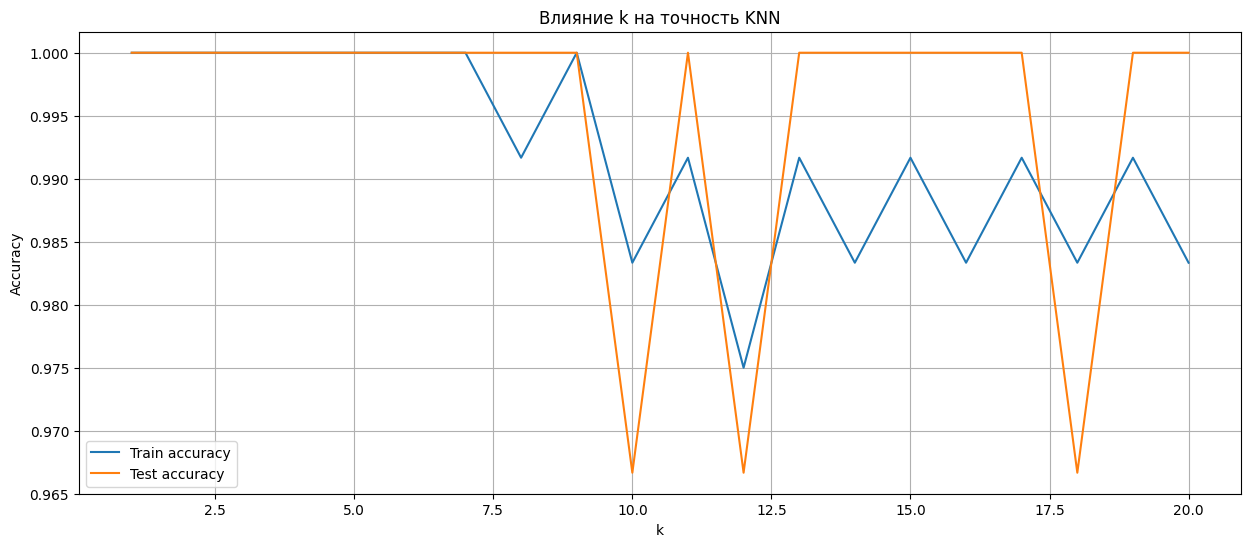

In [14]:
plt.figure(figsize=(15,6))
plt.plot(k_values, train_scores, label='Train accuracy')
plt.plot(k_values, test_scores, label='Test accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Влияние k на точность KNN')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# модель с масштабированием
test_scores_scaler = []

for k in k_values:
    knn_scaled = KNeighborsClassifier(n_neighbors=k)
    knn_scaled.fit(X_train_scaled, y_train)
    y_pred_scaled = knn_scaled.predict(X_test_scaled)
    test_scores_scaler.append(accuracy_score(y_test, y_pred_scaled))

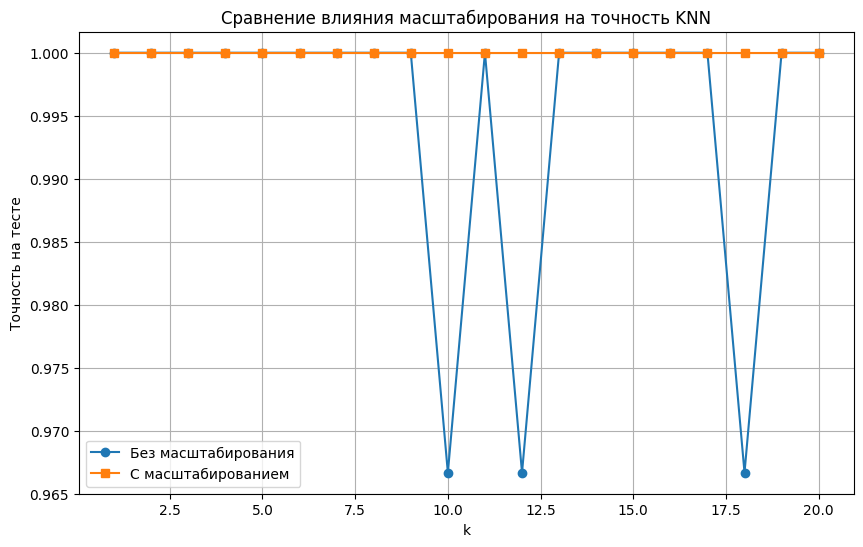

In [16]:
# Построим сравнение
plt.figure(figsize=(10,6))
plt.plot(k_values, test_scores, label='Без масштабирования', marker='o')
plt.plot(k_values, test_scores_scaler, label='С масштабированием', marker='s')
plt.xlabel('k')
plt.ylabel('Точность на тесте')
plt.title('Сравнение влияния масштабирования на точность KNN')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# меняю weights
train_scores.clear()
test_scores.clear()

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    train_scores.append(accuracy_score(y_train, y_train_pred))

    y_test_pred = knn.predict(X_test)
    test_scores.append(accuracy_score(y_test, y_test_pred))

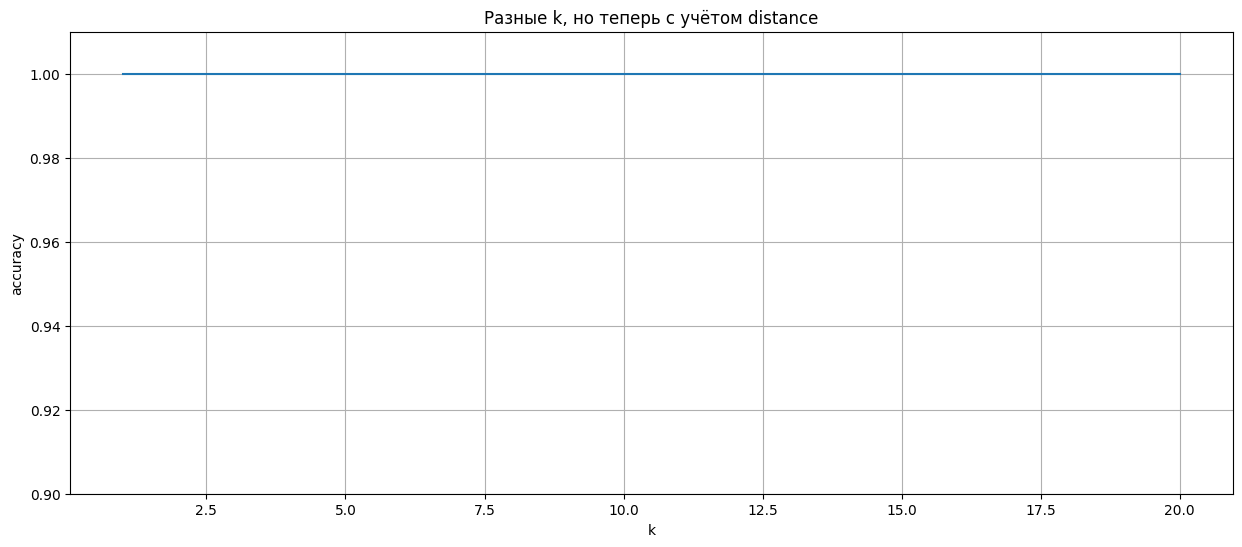

In [18]:
plt.figure(figsize=(15,6))
# plt.plot(k_values, train_scores, label='Train accuracy')
plt.plot(k_values, test_scores, label='Test accuracy')
plt.title('Разные k, но теперь с учётом distance')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.grid()
plt.ylim(0.9, 1.01)
plt.show()

я так понимаю, что дело в том, что расстояние точки до самой себя это бесконечно малое поэтому вес стремится к бесконечности и фактически не важно какие веса у других точек поэтому точность 1

In [19]:
# меняю метрику
train_scores.clear()
test_scores.clear()

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    train_scores.append(accuracy_score(y_train, y_train_pred))

    y_test_pred = knn.predict(X_test)
    test_scores.append(accuracy_score(y_test, y_test_pred))

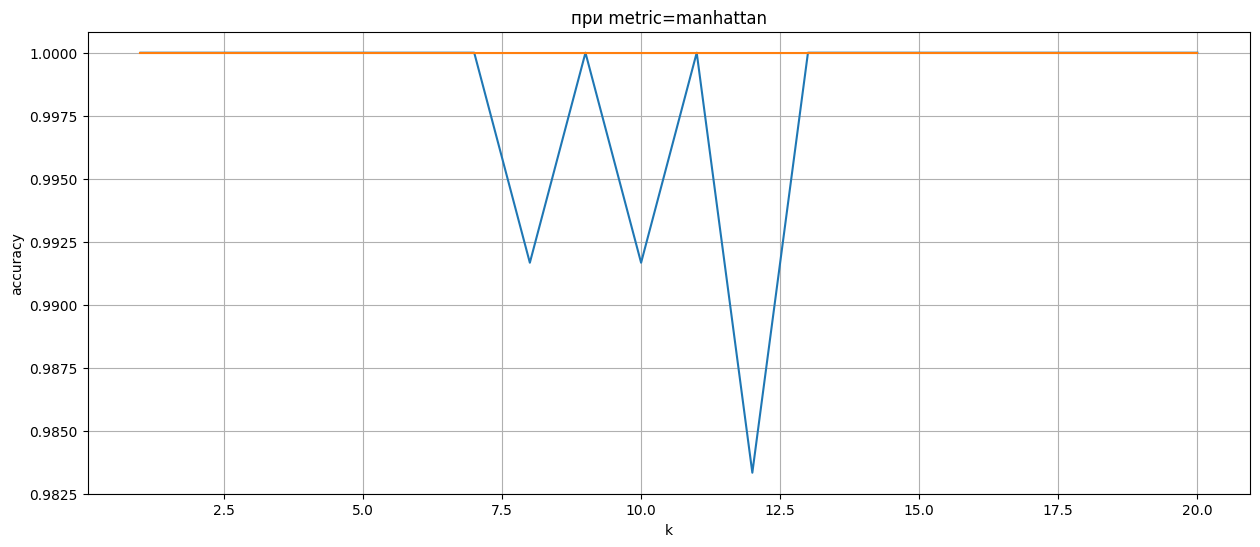

In [20]:
plt.figure(figsize=(15,6))
plt.plot(k_values, train_scores, label='Train accuracy')
plt.plot(k_values, test_scores, label='Test accuracy')
plt.title('при metric=manhattan')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.grid()
plt.show()

точность высокая, только видимо какие-то 1-2 объекта могли попадать не в свой класс для некоторых k на тренировочных данных

##### кросс-валидация
при k = 5

In [21]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())
pipeline.set_params(kneighborsclassifier__n_neighbors=5)
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"Точность на фолдах: {scores}")
print(f"Средняя точность: {scores.mean():.3f} +/- {scores.std():.3f}")

Точность на фолдах: [1. 1. 1. 1. 1.]
Средняя точность: 1.000 +/- 0.000


In [22]:
param_grid = {
    'kneighborsclassifier__n_neighbors': range(1, 21)
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучшее k:", grid_search.best_params_)
print("Лучшая средняя точность на кросс-валидации:", grid_search.best_score_)

Лучшее k: {'kneighborsclassifier__n_neighbors': 5}
Лучшая средняя точность на кросс-валидации: 1.0
